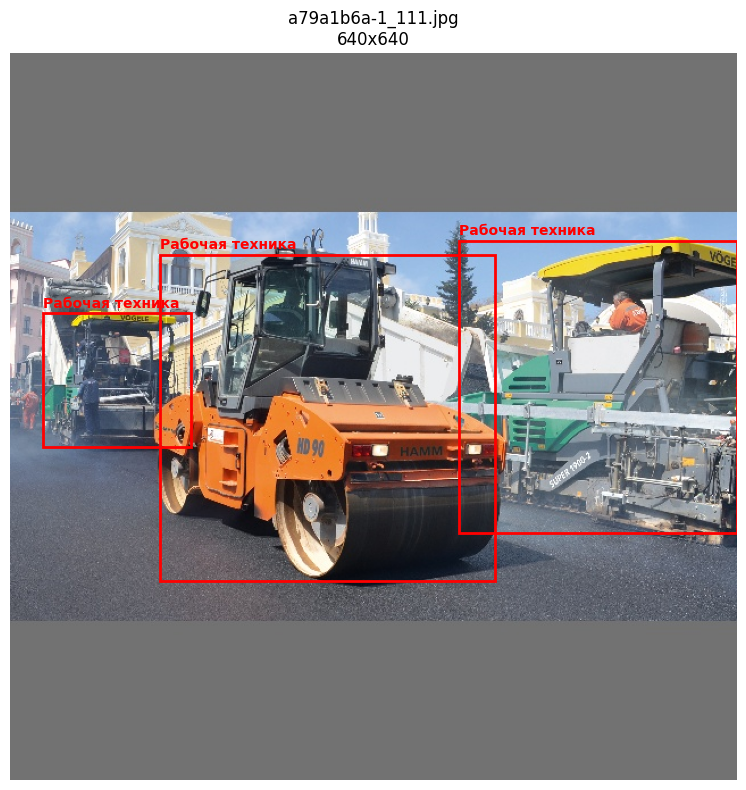

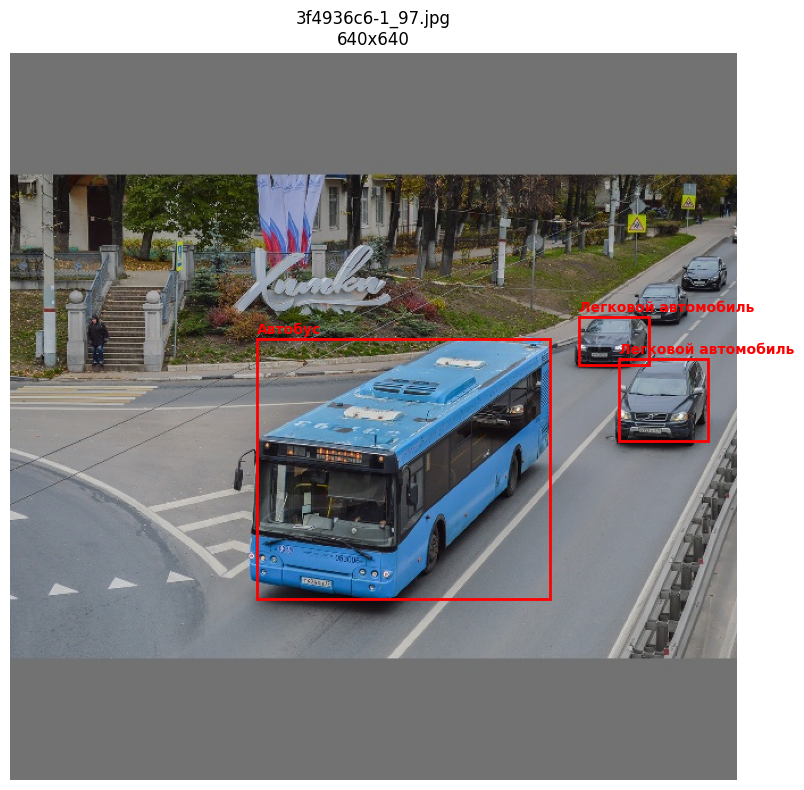

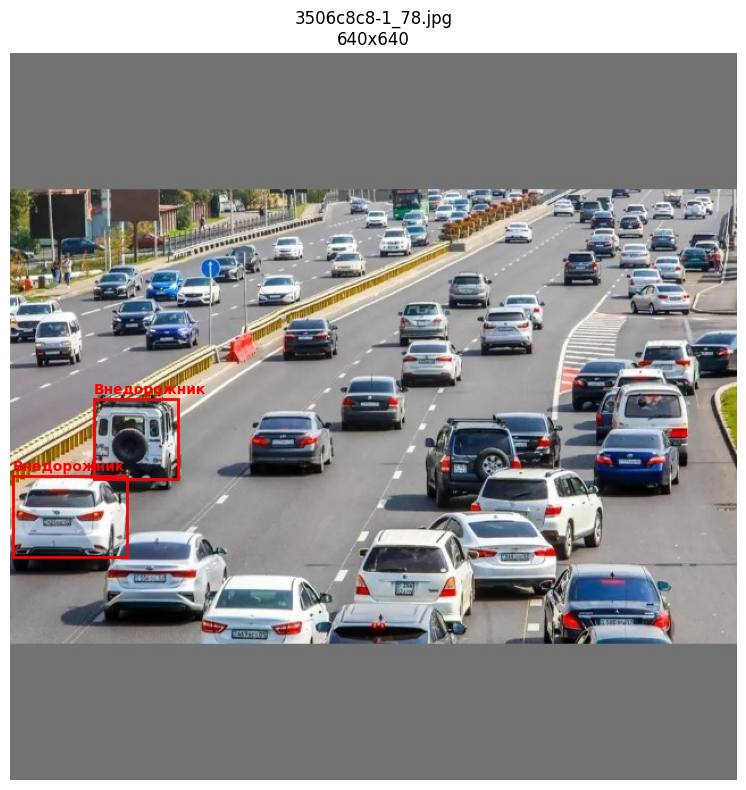

In [20]:
import json, shutil, cv2
from pathlib import Path
from sklearn.model_selection import train_test_split

class LabelStudioToYOLO:
    def __init__(self, json_path, images_dir, output_dir):
        self.json_path = json_path
        self.images_dir = Path(images_dir)
        self.output_dir = Path(output_dir)
        self.classes = []
        self.class_to_id = {}
        self.create_folders()
    
    def create_folders(self):
        folders = ['train/images','train/labels','val/images','val/labels','test/images','test/labels']
        for folder in folders:
            (self.output_dir/folder).mkdir(parents=True, exist_ok=True)
    
    def extract_classes(self):
        with open(self.json_path,'r',encoding='utf-8') as f:
            data=json.load(f)
        classes=set()
        for task in data:
            if task.get('annotations'):
                for ann in task['annotations']:
                    for r in ann['result']:
                        # Пропускаем элементы без 'value' или с типом 'relation'
                        if 'value' not in r or r.get('type') == 'relation':
                            continue
                        # Проверяем наличие rectanglelabels
                        if 'rectanglelabels' in r['value'] and r['value']['rectanglelabels']:
                            classes.add(r['value']['rectanglelabels'][0])
        self.classes=sorted(classes)
        self.class_to_id={c:i for i,c in enumerate(self.classes)}
        with open(self.output_dir/'classes.txt','w',encoding='utf-8') as f:
            for c in self.classes: f.write(f"{c}\n")
        return self.classes
    
    def find_image_file(self, image_name_from_json):
        name=Path(image_name_from_json.replace('\\','/').split('/')[-1])
        p=self.images_dir/name
        if p.exists(): return p
        for f in self.images_dir.glob('*'):
            if f.stem.endswith(name.stem) or name.stem.endswith(f.stem): return f
        return None
    
    def convert_annotation(self, result):
        # Пропускаем некорректные элементы
        if 'value' not in result or result.get('type') == 'relation':
            return None
        
        # Проверяем наличие всех необходимых полей
        required_fields = ['x', 'y', 'width', 'height', 'rectanglelabels']
        for field in required_fields:
            if field not in result['value']:
                return None
        
        x_left=result['value']['x']/100.0
        y_top=result['value']['y']/100.0
        width=result['value']['width']/100.0
        height=result['value']['height']/100.0
        x_center=x_left+width/2
        y_center=y_top+height/2
        class_id=self.class_to_id[result['value']['rectanglelabels'][0]]
        x_center=max(0.0,min(1.0,x_center))
        y_center=max(0.0,min(1.0,y_center))
        width=max(0.001,min(1.0,width))
        height=max(0.001,min(1.0,height))
        return f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}"
    
    def process_image(self, task, split='train'):
        image_path=self.find_image_file(task['data']['image'])
        if not image_path: return None
        dest_image_path=self.output_dir/split/'images'/image_path.name
        shutil.copy2(image_path, dest_image_path)
        label_path=self.output_dir/split/'labels'/f"{image_path.stem}.txt"
        
        annotations_written = False
        if task.get('annotations'):
            with open(label_path,'w',encoding='utf-8') as f:
                for ann in task['annotations']:
                    for r in ann['result']:
                        converted = self.convert_annotation(r)
                        if converted:
                            f.write(converted+'\n')
                            annotations_written = True
        
        # Если нет корректных аннотаций, создаем пустой файл
        if not annotations_written:
            open(label_path,'w').close()
            
        return dest_image_path.name
    
    def process_all(self, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1):
        with open(self.json_path,'r',encoding='utf-8') as f:
            data=json.load(f)
        self.extract_classes()
        
        # Фильтруем задачи с аннотациями (исключая те, где result пустой)
        tasks=[]
        for t in data:
            if t.get('annotations'):
                has_valid_annotations = False
                for ann in t['annotations']:
                    if ann.get('result'):
                        # Проверяем, есть ли хотя бы одна валидная аннотация с bounding box
                        for r in ann['result']:
                            if 'value' in r and r.get('type') != 'relation':
                                has_valid_annotations = True
                                break
                if has_valid_annotations:
                    tasks.append(t)
        
        # Разделение данных только если есть достаточное количество задач
        if len(tasks) > 1:
            train, temp = train_test_split(tasks, test_size=val_ratio+test_ratio, random_state=42)
            val, test = train_test_split(temp, test_size=test_ratio/(val_ratio+test_ratio), random_state=42)
        else:
            # Если только одна задача, используем её для тренировки
            train, val, test = tasks, [], []
            
        splits={'train':train,'val':val,'test':test}
        all_images={'train':[],'val':[],'test':[]}
        
        for split_name, task_list in splits.items():
            for task in task_list:
                img=self.process_image(task, split_name)
                if img: all_images[split_name].append(img)
                
        # Создаем data.yaml
        with open(self.output_dir/'data.yaml','w',encoding='utf-8') as f:
            f.write(f"path: {self.output_dir.absolute()}\n")
            f.write(f"train: train/images\n")
            f.write(f"val: val/images\n")
            f.write(f"test: test/images\n")
            f.write(f"nc: {len(self.classes)}\n")
            f.write(f"names: {self.classes}\n")
            
        return all_images

def validate_yolo_dataset(data_dir):
    from pathlib import Path
    import matplotlib.pyplot as plt, matplotlib.patches as patches
    import random
    data_dir=Path(data_dir)
    with open(data_dir/'classes.txt','r',encoding='utf-8') as f:
        classes=[line.strip() for line in f.readlines()]
    images_dir=data_dir/'train'/'images'
    labels_dir=data_dir/'train'/'labels'
    image_files=list(images_dir.glob('*.jpg'))+list(images_dir.glob('*.png'))
    for i in range(min(3, len(image_files))):
        img_path=random.choice(image_files)
        label_path=labels_dir/f"{img_path.stem}.txt"
        img=cv2.imread(str(img_path))
        img=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h,w=img.shape[:2]
        fig,ax=plt.subplots(1,figsize=(12,8))
        ax.imshow(img)
        if label_path.exists():
            with open(label_path,'r',encoding='utf-8') as f:
                for line in f:
                    parts=line.strip().split()
                    if len(parts)==5:
                        cid,xc,yc,wb,hb=map(float,parts)
                        x1=(xc-wb/2)*w
                        y1=(yc-hb/2)*h
                        rect=patches.Rectangle((x1,y1),wb*w,hb*h,linewidth=2,edgecolor='red',facecolor='none')
                        ax.add_patch(rect)
                        if int(cid)<len(classes):
                            ax.text(x1,y1-5,classes[int(cid)],color='red',fontsize=10,fontweight='bold')
        ax.set_title(f"{img_path.name}\n{w}x{h}")
        ax.axis('off')
        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    JSON_PATH = "datection.json"
    IMAGES_DIR = "data/upload/2"
    OUTPUT_DIR = "yolo_dataset"
    processor = LabelStudioToYOLO(JSON_PATH, IMAGES_DIR, OUTPUT_DIR)
    processor.process_all(train_ratio=0.7, val_ratio=0.15, test_ratio=0.15)
    validate_yolo_dataset(OUTPUT_DIR)